# Clustering with IMBD dataset
## using K-means


In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
datadir = "https://raw.githubusercontent.com/ahirtonlopes/Unsupervised_Learning/main/"

dataset = pd.read_csv(datadir + "IMDB_movie_dataset.csv", encoding='utf-8')

dataset.drop(['color','language'], axis= 1, inplace= True)

dataset.columns


Index(['director_name', 'duration', 'gross', 'genres', 'movie_title',
       'title_year', 'country', 'budget', 'imdb_score', 'actors',
       'movie_facebook_likes'],
      dtype='str')

In [3]:
dataset['gross'].fillna(0,inplace=True)
dataset['budget'].fillna(0,inplace=True)


/tmp/ipykernel_29959/1968742928.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  dataset['gross'].fillna(0,inplace=True)
/tmp/ipykernel_29959/1968742928.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update

0     100000000.0
1     200000000.0
2      44000000.0
3      14000000.0
4     225000000.0
         ...     
94     20000000.0
95            0.0
96     55000000.0
97     68000000.0
98     40000000.0
Name: budget, Length: 99, dtype: float64

In [4]:
dataset['country'] = dataset['country'].str.upper()
dataset['country'] = np.where(dataset['country']=='UNITED STATES','USA', dataset['country'])
dataset.head()


,director_name,duration,gross,genres,movie_title,title_year,country,budget,imdb_score,actors,movie_facebook_likes
0,Martin Scorsese,240,116866727.0,Biography|Comedy|Crime|Drama,The Wolf of Wall Street,2013,USA,100000000.0,8.2,"Leonardo DiCaprio,Matthew McConaughey,Jon Favreau",138000
1,Shane Black,195,408992272.0,Action|Adventure|Sci-Fi,Iron Man 3,2013,USA,200000000.0,7.2,"Robert Downey Jr.,Jon Favreau,Don Cheadle",95000
2,Quentin Tarantino,187,54116191.0,Crime|Drama|Mystery|Thriller|Western,The Hateful Eight,2015,USA,44000000.0,7.9,"Craig Stark,Jennifer Jason Leigh,Zoë Bell",114000
3,Kenneth Lonergan,186,46495.0,Drama,Margaret,2011,USA,14000000.0,6.5,"Matt Damon,Kieran Culkin,John Gallagher Jr.",0
4,Peter Jackson,186,258355354.0,Adventure|Fantasy,The Hobbit: The Desolation of Smaug,2013,USA,225000000.0,7.9,"Aidan Turner,Adam Brown,James Nesbitt",83000


In [5]:
dataset['director_name'] = np.where(dataset['director_name']=='N/A','',dataset['director_name'])
dataset['director_name'] = np.where(dataset['director_name']=='NaN','',dataset['director_name'])
dataset['director_name'] = np.where(dataset['director_name']=='Null','',dataset['director_name'])

dataset['movie_title'] = dataset['movie_title'].str.replace('Â','')


In [6]:
actor_list = dataset['actors'].str.split(',',n=2,expand=True)

dataset['actor1'] = actor_list[0]
dataset['actor2'] = actor_list[1]
dataset['actor3'] = actor_list[2]

dataset.drop(columns=['actors'],inplace=True)
dataset.head()


,director_name,duration,gross,genres,movie_title,title_year,country,budget,imdb_score,movie_facebook_likes,actor1,actor2,actor3
0,Martin Scorsese,240,116866727.0,Biography|Comedy|Crime|Drama,The Wolf of Wall Street,2013,USA,100000000.0,8.2,138000,Leonardo DiCaprio,Matthew McConaughey,Jon Favreau
1,Shane Black,195,408992272.0,Action|Adventure|Sci-Fi,Iron Man 3,2013,USA,200000000.0,7.2,95000,Robert Downey Jr.,Jon Favreau,Don Cheadle
2,Quentin Tarantino,187,54116191.0,Crime|Drama|Mystery|Thriller|Western,The Hateful Eight,2015,USA,44000000.0,7.9,114000,Craig Stark,Jennifer Jason Leigh,Zoë Bell
3,Kenneth Lonergan,186,46495.0,Drama,Margaret,2011,USA,14000000.0,6.5,0,Matt Damon,Kieran Culkin,John Gallagher Jr.
4,Peter Jackson,186,258355354.0,Adventure|Fantasy,The Hobbit: The Desolation of Smaug,2013,USA,225000000.0,7.9,83000,Aidan Turner,Adam Brown,James Nesbitt


In [7]:
dataset['duration'] = np.where(dataset['duration']<=10,0, dataset['duration'])
dataset['duration'] = np.where(dataset['duration']>=300,0, dataset['duration'])

dataset['imdb_score'] = np.where(dataset['imdb_score']<=0,0,dataset['imdb_score'])
dataset['title_year'] = np.where(dataset['title_year']<2010,0,dataset['title_year'])



In [8]:
dataset['GOB'] = dataset.apply(lambda row: row['gross']/row['budget'] if row['budget']!= 0 else 0 , axis=1)

top_GOB=dataset.sort_values('GOB',ascending=False).head(15)

In [9]:
top_GOB

,director_name,duration,gross,genres,movie_title,title_year,country,budget,imdb_score,movie_facebook_likes,actor1,actor2,actor3,GOB
43,Tate Taylor,146,169705587.0,Drama,The Help,2011,USA,25000000.0,8.1,75000,Emma Stone,Bryce Dallas Howard,Mike Vogel,6.788223
15,Richard Linklater,165,25359200.0,Drama,Boyhood,2014,USA,4000000.0,8.0,92000,Ellar Coltrane,Lorelei Linklater,Libby Villari,6.339800
14,F. Gary Gray,167,161029270.0,Biography|Crime|Drama|History|Music,Straight Outta Compton,2015,USA,28000000.0,7.9,76000,Aldis Hodge,Neil Brown Jr.,R. Marcos Taylor,5.751045
59,NaN,142,407999255.0,Adventure|Drama|Sci-Fi|Thriller,The Hunger Games,2012,USA,78000000.0,7.3,140000,Jennifer Lawrence,Josh Hutcherson,Anthony Reynolds,5.230760
75,NaN,138,150117807.0,Crime|Drama,American Hustle,2013,USA,40000000.0,7.3,63000,Jennifer Lawrence,Christian Bale,Bradley Cooper,3.752945
44,Francis Lawrence,146,424645577.0,Adventure|Sci-Fi|Thriller,The Hunger Games: Catching Fire,2013,USA,130000000.0,7.6,82000,Jennifer Lawrence,Josh Hutcherson,Sandra Ellis Lafferty,3.266504
76,Robert Zemeckis,138,93749203.0,Drama|Thriller,Flight,2012,USA,31000000.0,7.3,64000,Denzel Washington,Bruce Greenwood,Nadine Velazquez,3.024168
94,Steve McQueen,134,56667870.0,Biography|Drama|History,12 Years a Slave,2013,USA,20000000.0,8.1,83000,Quvenzhané Wallis,Scoot McNairy,Taran Killam,2.833394
8,Joss Whedon,173,623279547.0,Action|Adventure|Sci-Fi,The Avengers,2012,USA,220000000.0,8.1,123000,Chris Hemsworth,Robert Downey Jr.,Scarlett Johansson,2.833089
9,Joss Whedon,173,623279547.0,Action|Adventure|Sci-Fi,The Avengers,2012,USA,220000000.0,8.1,123000,Chris Hemsworth,Robert Downey Jr.,Scarlett Johansson,2.833089


In [10]:
top_GOB['director_familyName'] = dataset['director_name'].str.split(" ",n=2, expand = True) [1]
top_GOB

,director_name,duration,gross,genres,movie_title,title_year,country,budget,imdb_score,movie_facebook_likes,actor1,actor2,actor3,GOB,director_familyName
43,Tate Taylor,146,169705587.0,Drama,The Help,2011,USA,25000000.0,8.1,75000,Emma Stone,Bryce Dallas Howard,Mike Vogel,6.788223,Taylor
15,Richard Linklater,165,25359200.0,Drama,Boyhood,2014,USA,4000000.0,8.0,92000,Ellar Coltrane,Lorelei Linklater,Libby Villari,6.339800,Linklater
14,F. Gary Gray,167,161029270.0,Biography|Crime|Drama|History|Music,Straight Outta Compton,2015,USA,28000000.0,7.9,76000,Aldis Hodge,Neil Brown Jr.,R. Marcos Taylor,5.751045,Gary
59,NaN,142,407999255.0,Adventure|Drama|Sci-Fi|Thriller,The Hunger Games,2012,USA,78000000.0,7.3,140000,Jennifer Lawrence,Josh Hutcherson,Anthony Reynolds,5.230760,NaN
75,NaN,138,150117807.0,Crime|Drama,American Hustle,2013,USA,40000000.0,7.3,63000,Jennifer Lawrence,Christian Bale,Bradley Cooper,3.752945,NaN
44,Francis Lawrence,146,424645577.0,Adventure|Sci-Fi|Thriller,The Hunger Games: Catching Fire,2013,USA,130000000.0,7.6,82000,Jennifer Lawrence,Josh Hutcherson,Sandra Ellis Lafferty,3.266504,Lawrence
76,Robert Zemeckis,138,93749203.0,Drama|Thriller,Flight,2012,USA,31000000.0,7.3,64000,Denzel Washington,Bruce Greenwood,Nadine Velazquez,3.024168,Zemeckis
94,Steve McQueen,134,56667870.0,Biography|Drama|History,12 Years a Slave,2013,USA,20000000.0,8.1,83000,Quvenzhané Wallis,Scoot McNairy,Taran Killam,2.833394,McQueen
8,Joss Whedon,173,623279547.0,Action|Adventure|Sci-Fi,The Avengers,2012,USA,220000000.0,8.1,123000,Chris Hemsworth,Robert Downey Jr.,Scarlett Johansson,2.833089,Whedon
9,Joss Whedon,173,623279547.0,Action|Adventure|Sci-Fi,The Avengers,2012,USA,220000000.0,8.1,123000,Chris Hemsworth,Robert Downey Jr.,Scarlett Johansson,2.833089,Whedon


/tmp/ipykernel_29959/2225654355.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),rotation=45)


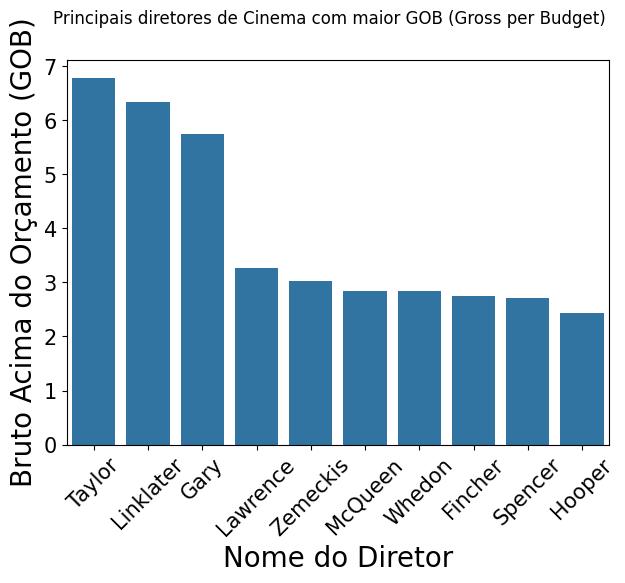

In [11]:
fig,ax = plt.subplots(figsize=(7,5))

ax = sns.barplot(x='director_familyName', y='GOB', data=top_GOB)
ax.set_xticklabels(ax.get_xticklabels(),rotation=45)

fig.suptitle("Principais diretores de Cinema com maior GOB (Gross per Budget)", fontsize=12)

ax.set_xlabel("Nome do Diretor",fontsize=20)
ax.set_ylabel("Bruto Acima do Orçamento (GOB)",fontsize=20)

ax.tick_params(axis='x',labelsize=15)
ax.tick_params(axis='y',labelsize=15)

plt.show()

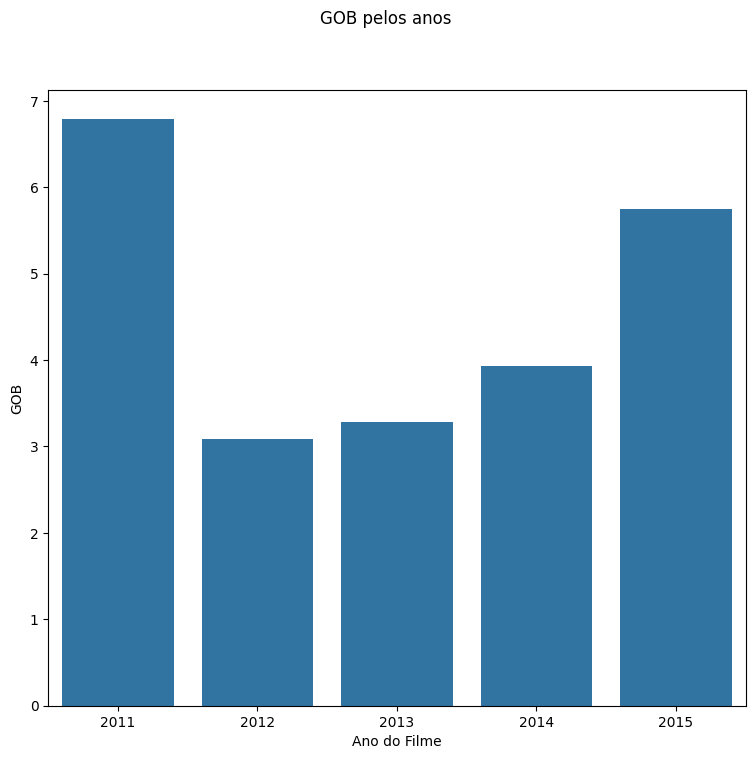

In [13]:
dataset_pivot = top_GOB.pivot_table(index=['title_year'], values=['GOB'], aggfunc=np.mean , margins=True)


dataset_pivot = dataset_pivot[:-1]

dataset_pivot.reset_index(inplace=True)

fig,ax = plt.subplots(figsize=(9,8))

ax=sns.barplot(x="title_year",y="GOB", data=dataset_pivot)

fig.suptitle("GOB pelos anos",fontsize=12)

plt.xlabel("Ano do Filme")
plt.show()

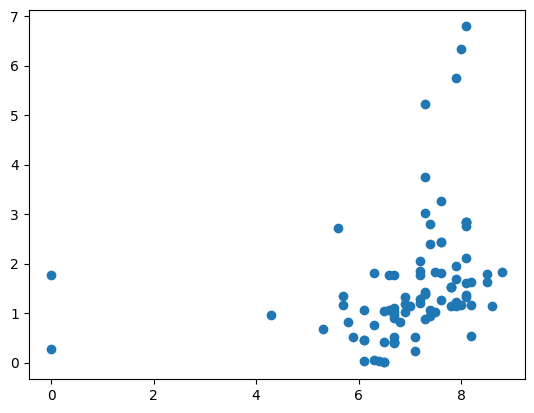

In [14]:
plt.scatter(x=dataset["imdb_score"], y=dataset['GOB'])
plt.show()

## Clustering with 3 groups

In [17]:
selected_dataset = dataset.loc[(dataset['GOB']>0) & (dataset['imdb_score']>0)][['imdb_score','GOB']]


cls = KMeans(n_clusters=3)

cls.fit(selected_dataset)

centroids=cls.cluster_centers_

labels = cls.labels_

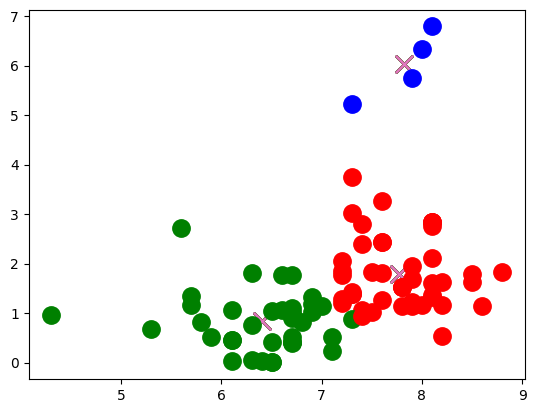

In [19]:
colors = ["g.","r.","b.","y.","p"]



dataset_array = np.array(selected_dataset)



for i in range(len(dataset_array)):
    plt.plot(dataset_array[i][0], dataset_array[i][1], colors [labels[i]],markersize=25)
    plt.scatter(centroids[:,0], centroids[:,1], marker="x", s= 150)